# 03 · Block-level regression (milestone M3)

LST ~ material fractions + vegetation + built form, fitted on urban blocks of the model area. R² is reported with **spatial** cross-validation (1 km tiles held out together), because neighbouring blocks share heat and random folds would overstate accuracy.

All temperatures are **land surface temperature**, not air temperature.

**Cool roofs** use a literature coefficient (Wang, Huang & Li 2020, GRL; sources in `config/aoi.yaml`) because the interim Sentinel-2 regression gives dark roofs a cooling sign, likely from building shadow. **Trees** use the fitted coefficients.

In [1]:
%matplotlib inline
import matplotlib.pyplot as plt
from coolcairo.config import load_config, geobox_for
cfg = load_config()

In [2]:
from coolcairo.pipeline import build_blocks
from coolcairo.model import fit, training_rows, FEATURES
blocks, material, buildings = build_blocks(cfg)
train = training_rows(blocks, cfg['min_building_coverage'])
result = fit(train, cfg['cv_tile_size'], cfg['cv_folds'])
result.to_dict()

{'intercept': 45.83081831190092,
 'coefficients': {'veg_frac': -3.1510116156998995,
  'dark_roof_frac': -11.275863613957034,
  'dark_ground_frac': 0.12490041353330779,
  'soil_frac': 3.3635322626888087,
  'roof_frac': 2.2896142922594,
  'mean_height_m': -0.06169070606957128},
 'r2_train': 0.3784385631901346,
 'r2_spatial_cv': 0.25010842084884644,
 'mae_spatial_cv': 1.1986862421035767,
 'n_blocks': 2538,
 'cv_folds': 5,
 'cv_tile_size_m': 1000}

In [3]:
from coolcairo.interventions import full_adoption_summary, plausibility_warnings, cool_roof_surface_deltas
print(plausibility_warnings(cfg, result) or 'Coefficient signs plausible.')
cr = cfg['cool_roof']
roof = cool_roof_surface_deltas(cfg, result)
print(f"Cool roof ({cr['method']}), surface temperature per unit block area coated:")
print(f"  dark roof {roof.dark:+.2f} °C = {cr['dts_per_albedo']} K/albedo x ({cr['albedo_after']} - {cr['albedo_dark_roof']})")
print(f"  pale roof {roof.pale:+.2f} °C = {cr['dts_per_albedo']} K/albedo x ({cr['albedo_after']} - {cr['albedo_pale_roof']})")
full_adoption_summary(cfg, result, train).round(2)

['Fitted dark roofs do not raise LST vs bright roofs (literature value in use).']
Cool roof (literature), surface temperature per unit block area coated:
  dark roof -4.64 °C = -8.0 K/albedo x (0.7 - 0.12)
  pale roof -3.60 °C = -8.0 K/albedo x (0.7 - 0.25)


,cool_roofs,street_trees,cool_pavements,pocket_parks
count,2538.00,2538.00,2538.00,2538.00
mean,-1.01,-0.09,-0.25,-0.74
std,0.59,0.12,0.32,0.64
min,-3.66,-0.64,-1.74,-2.90
25%,-1.24,-0.13,-0.36,-1.13
50%,-0.84,-0.04,-0.11,-0.56
75%,-0.58,-0.00,-0.00,-0.24
max,-0.06,-0.00,-0.00,-0.00


Text(0.5, 1.0, 'Spatial-CV R² = 0.25')

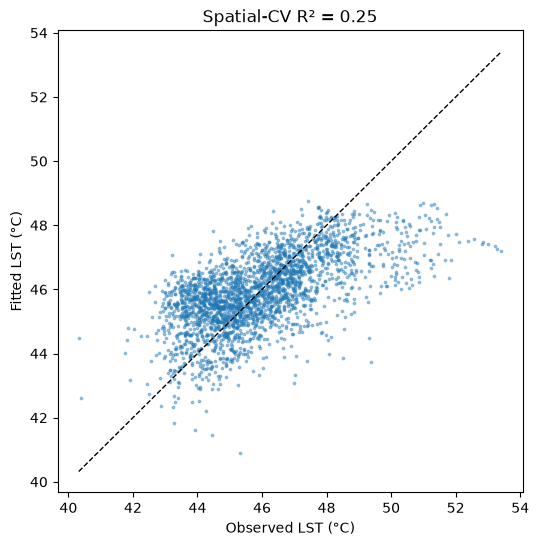

In [4]:
import numpy as np
pred = result.intercept + train[FEATURES].to_numpy() @ np.array([result.coefficients[f] for f in FEATURES])
plt.figure(figsize=(6, 6))
plt.scatter(train.lst_c, pred, s=3, alpha=0.4)
lo, hi = train.lst_c.min(), train.lst_c.max()
plt.plot([lo, hi], [lo, hi], 'k--', lw=1)
plt.xlabel('Observed LST (°C)'); plt.ylabel('Fitted LST (°C)')
plt.title(f"Spatial-CV R² = {result.r2_spatial_cv:.2f}")

## Heat risk (heat exposure)
Heat exposure = residents (WorldPop 2024, 100 m constrained) × °C above the reference surface temperature, which is the median summer LST of urban blocks in the model area. It is a hazard × exposure screening indicator in person·°C; vulnerability (age, housing, access to cooling) is not included. Figures below are for the display district, and match the Unity readouts.

In [5]:
from coolcairo.interventions import heat_reference_c, exposure_reduction_summary
from coolcairo.pipeline import display_subset
reference = heat_reference_c(cfg, train)
district, _ = display_subset(cfg, blocks, buildings)
exposure_reduction_summary(cfg, result, district.dropna(subset=['lst_c']), reference).round(2)

residents               95140.61
reference_c                45.66
exposure_person_degC     6459.75
cool_roofs_pct            -41.39
street_trees_pct          -23.71
cool_pavements_pct        -52.33
pocket_parks_pct          -60.23
dtype: float64